<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Derived_Form_Factor_Locked_Scattering_Retest_V33_CLEAN_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Derived Form-Factor Locked Scattering Retest V33

Full multi-cell notebook with explicit markdown sections and visual exports.

## How to run
Run all cells. In Colab, outputs are written to `/content/ecsm_electron_like_derived_form_factor_locked_scattering_v33_v2_out`.

In [1]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/content') if Path('/content').exists() else Path('/mnt/data')
OUT = BASE / 'ecsm_electron_like_derived_form_factor_locked_scattering_v33_v2_out'
OUT.mkdir(parents=True, exist_ok=True)

q_eff = -0.9993035720499918
E_rest_keV = 514.0698767738036
alpha_fs = 0.0072973525692838015
k_response_chi1_keV = 5140.698767738036
Pi_ecsm_plateau_locked = 0.007146727844882419
print('Output directory:', OUT)

Output directory: /content/ecsm_electron_like_derived_form_factor_locked_scattering_v33_v2_out


## Locked functions
V33 uses a Gaussian-density form factor derived from the inherited response scale.

In [2]:
def leading_log_pi(q_keV):
    c = 2 * alpha_fs / (3 * np.pi)
    return c * np.log1p((q_keV / E_rest_keV)**2)

def locked_pi_ecsm(q_keV, k=k_response_chi1_keV):
    pi_ref = leading_log_pi(q_keV)
    sat = Pi_ecsm_plateau_locked * (q_keV**2 / (q_keV**2 + k**2))
    return np.minimum(pi_ref, sat)

def alpha_from_pi(pi):
    return alpha_fs / (1 - pi)

def running_alpha_ratio(q_keV):
    return alpha_from_pi(locked_pi_ecsm(q_keV)) / alpha_from_pi(leading_log_pi(q_keV))

def F_v29(q_keV):
    return 1 / (1 + q_keV / k_response_chi1_keV)

def F_gaussian_density(q_keV):
    return np.exp(-np.minimum((q_keV / k_response_chi1_keV)**2 / 6.0, 350.0))

## Generate angular grid

In [3]:
T_values = np.array([10.0, 100.0, 1000.0, 5000.0])
theta_deg = np.linspace(1.0, 179.0, 800)
rows = []
for T in T_values:
    p = np.sqrt(T * (T + 2 * E_rest_keV))
    beta = p / (T + E_rest_keV)
    q = 2 * p * np.sin(np.deg2rad(theta_deg) / 2)
    mott = 1 - beta**2 * np.sin(np.deg2rad(theta_deg) / 2)**2
    q90 = 2 * p * np.sin(np.deg2rad(90.0) / 2)
    mott90 = 1 - beta**2 * np.sin(np.deg2rad(90.0) / 2)**2
    sigma_ref_norm = (mott / mott90) * (q90 / q)**4
    ar = running_alpha_ratio(q)
    ratio_v29 = (F_v29(q) * ar)**2
    ratio_v33 = (F_gaussian_density(q) * ar)**2
    for i in range(len(theta_deg)):
        rows.append({
            'T_keV': T, 'theta_deg': float(theta_deg[i]), 'p_keV': float(p), 'beta_rel': float(beta),
            'q_transfer_keV': float(q[i]), 'mott_spin_factor': float(mott[i]),
            'sigma_ref_norm_to_ref90': float(sigma_ref_norm[i]),
            'sigma_v29_norm_to_ref90': float(sigma_ref_norm[i] * ratio_v29[i]),
            'sigma_v33_norm_to_ref90': float(sigma_ref_norm[i] * ratio_v33[i]),
            'ratio_v29_to_ref': float(ratio_v29[i]), 'ratio_v33_to_ref': float(ratio_v33[i]),
            'relative_shape_difference_v29': float(abs(1 - ratio_v29[i])),
            'relative_shape_difference_v33': float(abs(1 - ratio_v33[i])),
            'form_factor_v29': float(F_v29(q)[i]),
            'form_factor_v33_gaussian_density': float(F_gaussian_density(q)[i]),
            'running_alpha_ratio': float(ar[i])
        })
angular_df = pd.DataFrame(rows)
angular_df.to_csv(OUT / 'locked_elastic_scattering_shape_retest_v33.csv', index=False)
angular_df.head()

,T_keV,theta_deg,p_keV,beta_rel,q_transfer_keV,mott_spin_factor,sigma_ref_norm_to_ref90,sigma_v29_norm_to_ref90,sigma_v33_norm_to_ref90,ratio_v29_to_ref,ratio_v33_to_ref,relative_shape_difference_v29,relative_shape_difference_v33,form_factor_v29,form_factor_v33_gaussian_density,running_alpha_ratio
0,10.0,1.000000,101.889143,0.194419,1.778278,0.999997,4.393977e+07,4.390938e+07,4.393977e+07,0.999308,1.0,0.000692,7.523698e-08,0.999654,1.0,1.0
1,10.0,1.222778,101.889143,0.194419,2.174427,0.999996,1.965518e+07,1.963856e+07,1.965517e+07,0.999155,1.0,0.000845,1.124918e-07,0.999577,1.0,1.0
2,10.0,1.445557,101.889143,0.194419,2.570567,0.999994,1.006328e+07,1.005322e+07,1.006328e+07,0.999001,1.0,0.000999,1.572130e-07,0.999500,1.0,1.0
3,10.0,1.668335,101.889143,0.194419,2.966698,0.999992,5.672329e+06,5.665787e+06,5.672327e+06,0.998847,1.0,0.001153,2.093997e-07,0.999423,1.0,1.0
4,10.0,1.891114,101.889143,0.194419,3.362817,0.999990,3.435901e+06,3.431410e+06,3.435900e+06,0.998693,1.0,0.001307,2.690512e-07,0.999346,1.0,1.0


## Figure 1 — Scattering shape comparison

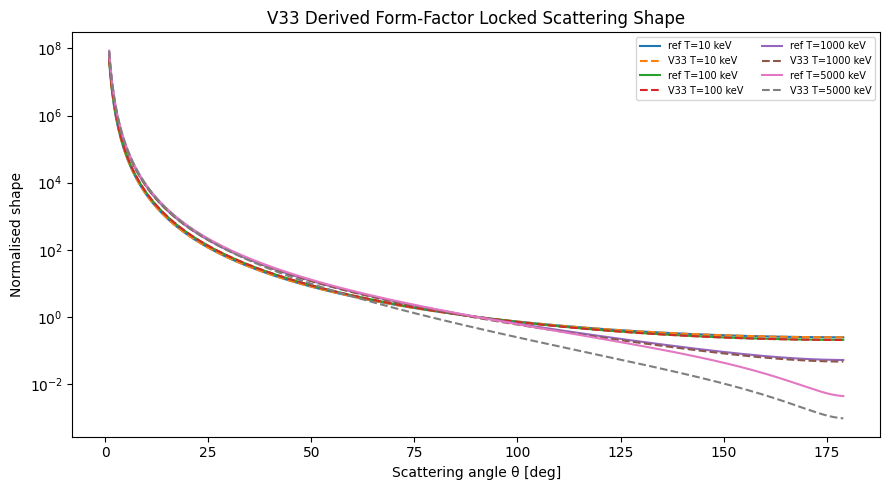

In [4]:
plt.figure(figsize=(9, 5))
for T in T_values:
    d = angular_df[angular_df.T_keV == T]
    plt.plot(d.theta_deg, d.sigma_ref_norm_to_ref90, label=f'ref T={T:g} keV')
    plt.plot(d.theta_deg, d.sigma_v33_norm_to_ref90, linestyle='--', label=f'V33 T={T:g} keV')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Normalised shape')
plt.title('V33 Derived Form-Factor Locked Scattering Shape')
plt.legend(fontsize=7, ncol=2); plt.tight_layout()
plt.savefig(OUT / 'fig_v33_derived_form_factor_scattering_shape_comparison.png', dpi=200)
plt.show()

## Low-transfer correspondence and V32 residual reduction

In [5]:
q_low_max = 1268.2050944324717
low_df = angular_df[angular_df.q_transfer_keV <= q_low_max].copy()
low_summary = {
    'q_low_max_keV': q_low_max,
    'n_low_transfer_points': int(len(low_df)),
    'v32_max_low_transfer_shape_relative_difference': 0.35709712178889474,
    'v32_mean_low_transfer_shape_relative_difference': 0.11318908339206013,
    'max_low_transfer_shape_relative_difference_v33': float(low_df.relative_shape_difference_v33.max()),
    'mean_low_transfer_shape_relative_difference_v33': float(low_df.relative_shape_difference_v33.mean()),
    'median_low_transfer_shape_relative_difference_v33': float(low_df.relative_shape_difference_v33.median()),
    'passes_low_transfer_max_threshold_0p06': bool(low_df.relative_shape_difference_v33.max() <= 0.06),
    'passes_low_transfer_mean_threshold_0p005': bool(low_df.relative_shape_difference_v33.mean() <= 0.005),
    'improvement_factor_max_vs_v32': float(0.35709712178889474 / low_df.relative_shape_difference_v33.max()),
    'improvement_factor_mean_vs_v32': float(0.11318908339206013 / low_df.relative_shape_difference_v33.mean())
}
low_df.to_csv(OUT / 'low_transfer_derived_form_factor_shape_correspondence_v33.csv', index=False)
(OUT / 'low_transfer_derived_form_factor_shape_correspondence_summary_v33.json').write_text(json.dumps(low_summary, indent=2))
print(json.dumps(low_summary, indent=2))

{
  "q_low_max_keV": 1268.2050944324717,
  "n_low_transfer_points": 1889,
  "v32_max_low_transfer_shape_relative_difference": 0.35709712178889474,
  "v32_mean_low_transfer_shape_relative_difference": 0.11318908339206013,
  "max_low_transfer_shape_relative_difference_v33": 0.02517755452141679,
  "mean_low_transfer_shape_relative_difference_v33": 0.0035746506191918566,
  "median_low_transfer_shape_relative_difference_v33": 0.0009434017880166623,
  "passes_low_transfer_max_threshold_0p06": true,
  "passes_low_transfer_mean_threshold_0p005": true,
  "improvement_factor_max_vs_v32": 14.18315354992627,
  "improvement_factor_mean_vs_v32": 31.664376592319808
}


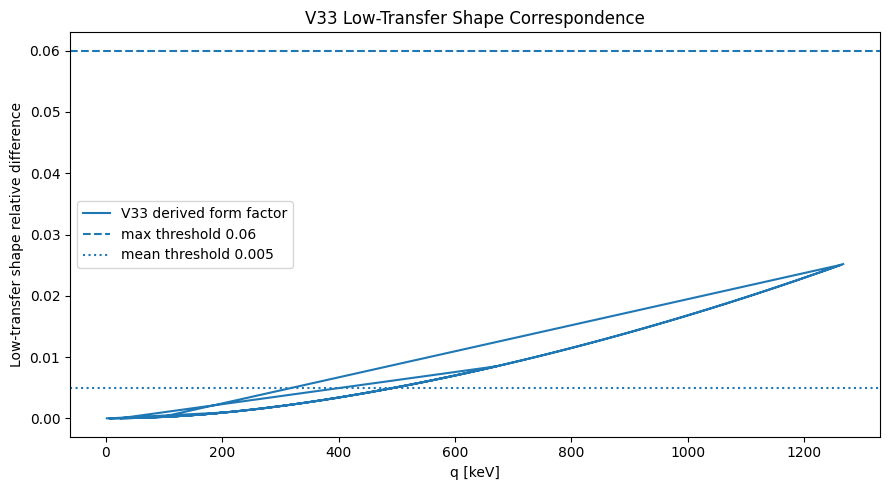

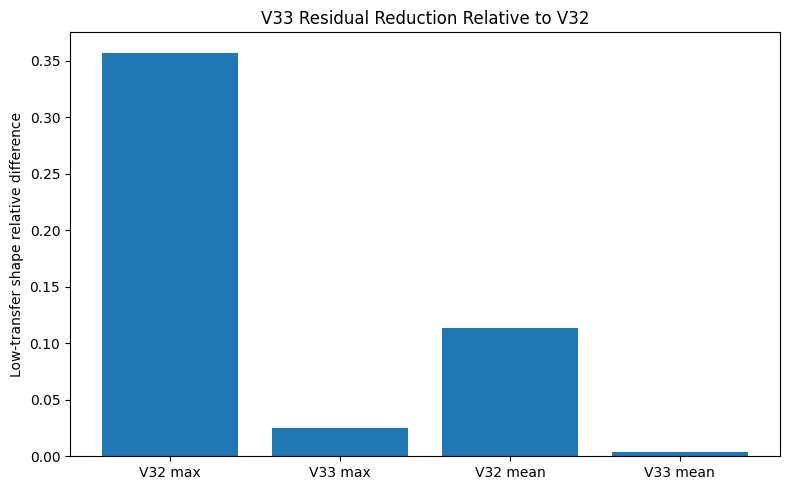

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(low_df.q_transfer_keV, low_df.relative_shape_difference_v33, label='V33 derived form factor')
plt.axhline(0.06, linestyle='--', label='max threshold 0.06')
plt.axhline(0.005, linestyle=':', label='mean threshold 0.005')
plt.xlabel('q [keV]'); plt.ylabel('Low-transfer shape relative difference')
plt.title('V33 Low-Transfer Shape Correspondence')
plt.legend(); plt.tight_layout()
plt.savefig(OUT / 'fig_v33_low_transfer_shape_correspondence.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
labels = ['V32 max', 'V33 max', 'V32 mean', 'V33 mean']
values = [0.35709712178889474, low_summary['max_low_transfer_shape_relative_difference_v33'],
          0.11318908339206013, low_summary['mean_low_transfer_shape_relative_difference_v33']]
plt.bar(labels, values); plt.ylabel('Low-transfer shape relative difference')
plt.title('V33 Residual Reduction Relative to V32')
plt.tight_layout(); plt.savefig(OUT / 'fig_v33_v32_residual_reduction.png', dpi=200)
plt.show()

## Large-angle and extreme-transfer suppression

{
  "fixed_grid_q_max_keV": 10979.69097571184,
  "ratio_v33_to_ref_at_fixed_grid_qmax": 0.21699058047365105,
  "ratio_v29_to_ref_at_fixed_grid_qmax_comparison": 0.10095360288223393,
  "theta_at_fixed_grid_qmax_deg": 179.0,
  "T_at_fixed_grid_qmax_keV": 5000.0,
  "mean_ratio_large_angle_T5000_theta_ge_120_v33": 0.24956257748257551,
  "min_ratio_large_angle_T5000_theta_ge_120_v33": 0.21699058047365105,
  "max_ratio_large_angle_T5000_theta_ge_120_v33": 0.31671578047998944,
  "finite_large_angle_suppression_pass": true
}


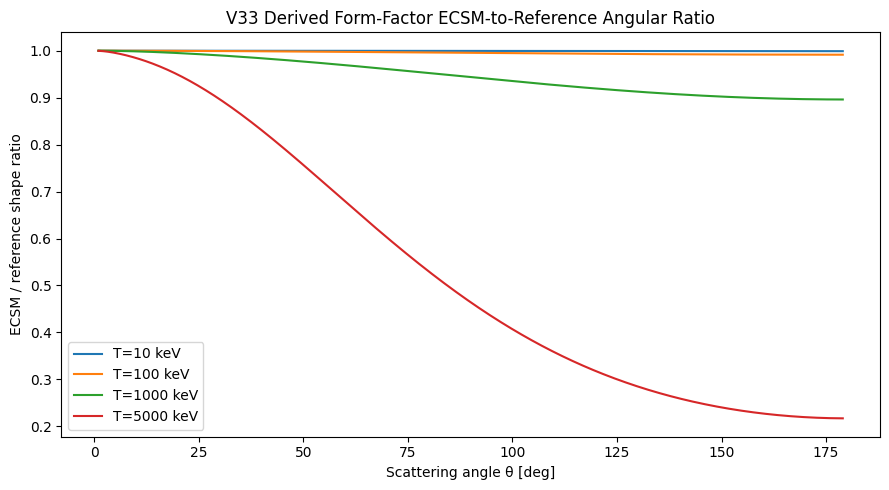

In [7]:
fixed_max_row = angular_df.loc[angular_df.q_transfer_keV.idxmax()]
large_angle = angular_df[(angular_df.T_keV == 5000.0) & (angular_df.theta_deg >= 120)]
fixed_summary = {
    'fixed_grid_q_max_keV': float(fixed_max_row.q_transfer_keV),
    'ratio_v33_to_ref_at_fixed_grid_qmax': float(fixed_max_row.ratio_v33_to_ref),
    'ratio_v29_to_ref_at_fixed_grid_qmax_comparison': float(fixed_max_row.ratio_v29_to_ref),
    'theta_at_fixed_grid_qmax_deg': float(fixed_max_row.theta_deg),
    'T_at_fixed_grid_qmax_keV': float(fixed_max_row.T_keV),
    'mean_ratio_large_angle_T5000_theta_ge_120_v33': float(large_angle.ratio_v33_to_ref.mean()),
    'min_ratio_large_angle_T5000_theta_ge_120_v33': float(large_angle.ratio_v33_to_ref.min()),
    'max_ratio_large_angle_T5000_theta_ge_120_v33': float(large_angle.ratio_v33_to_ref.max()),
    'finite_large_angle_suppression_pass': bool(fixed_max_row.ratio_v33_to_ref < 0.8 and fixed_max_row.ratio_v33_to_ref > 0)
}
large_angle.to_csv(OUT / 'large_angle_derived_form_factor_suppression_v33.csv', index=False)
(OUT / 'large_angle_derived_form_factor_suppression_summary_v33.json').write_text(json.dumps(fixed_summary, indent=2))
print(json.dumps(fixed_summary, indent=2))

plt.figure(figsize=(9, 5))
for T in T_values:
    d = angular_df[angular_df.T_keV == T]
    plt.plot(d.theta_deg, d.ratio_v33_to_ref, label=f'T={T:g} keV')
plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('ECSM / reference shape ratio')
plt.title('V33 Derived Form-Factor ECSM-to-Reference Angular Ratio')
plt.legend(); plt.tight_layout()
plt.savefig(OUT / 'fig_v33_ecsm_to_reference_angular_ratio.png', dpi=200)
plt.show()

{
  "q_min_keV": 0.01,
  "q_max_keV": 100000000.0,
  "all_amplitudes_finite": true,
  "amplitude_ratio_at_1e8_keV": 9.623851210167468e-153,
  "cross_section_ratio_at_1e8_keV": 9.261851211544184e-305,
  "passes_extreme_transfer_finite_suppression": true
}


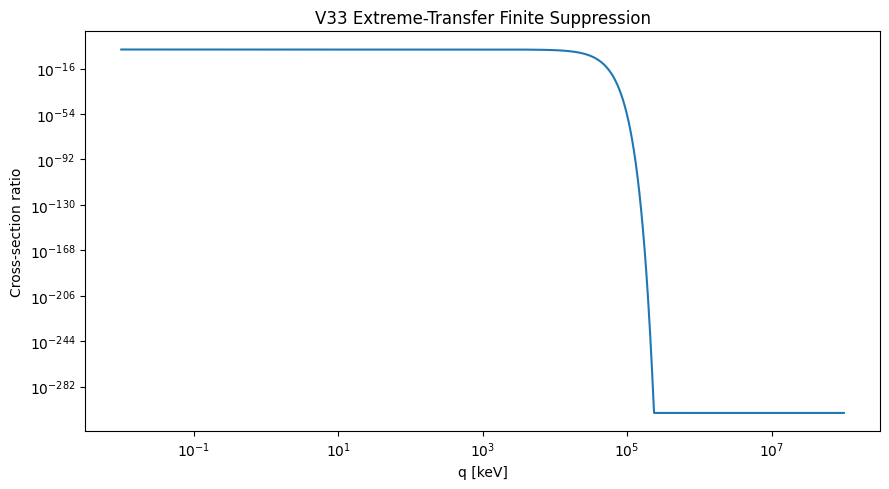

In [8]:
q_grid = np.logspace(-2, 8, 1600)
amp_ratio_v33 = F_gaussian_density(q_grid) * running_alpha_ratio(q_grid)
cross_ratio_v33 = amp_ratio_v33**2
extreme_df = pd.DataFrame({
    'q_keV': q_grid,
    'amplitude_ratio_v33_to_ref': amp_ratio_v33,
    'cross_section_ratio_v33_to_ref': cross_ratio_v33,
    'form_factor_v33_gaussian_density': F_gaussian_density(q_grid),
    'running_alpha_ratio': running_alpha_ratio(q_grid)
})
extreme_df.to_csv(OUT / 'extreme_transfer_derived_form_factor_suppression_v33.csv', index=False)
extreme_summary = {
    'q_min_keV': float(q_grid.min()),
    'q_max_keV': float(q_grid.max()),
    'all_amplitudes_finite': bool(np.isfinite(amp_ratio_v33).all()),
    'amplitude_ratio_at_1e8_keV': float(amp_ratio_v33[-1]),
    'cross_section_ratio_at_1e8_keV': float(cross_ratio_v33[-1]),
    'passes_extreme_transfer_finite_suppression': bool(np.isfinite(cross_ratio_v33[-1]) and cross_ratio_v33[-1] < 1e-6)
}
(OUT / 'extreme_transfer_derived_form_factor_suppression_summary_v33.json').write_text(json.dumps(extreme_summary, indent=2))
print(json.dumps(extreme_summary, indent=2))

plt.figure(figsize=(9, 5))
plt.plot(extreme_df.q_keV, extreme_df.cross_section_ratio_v33_to_ref)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('q [keV]'); plt.ylabel('Cross-section ratio')
plt.title('V33 Extreme-Transfer Finite Suppression')
plt.tight_layout(); plt.savefig(OUT / 'fig_v33_extreme_transfer_finite_suppression.png', dpi=200)
plt.show()

## Chi deformation

{
  "chi_values": [
    1.0,
    0.95,
    0.8,
    0.5,
    0.2
  ],
  "finite_all_chi": true,
  "min_cross_section_ratio": 0.0006516603050653421,
  "max_cross_section_ratio": 0.8965155634529044
}


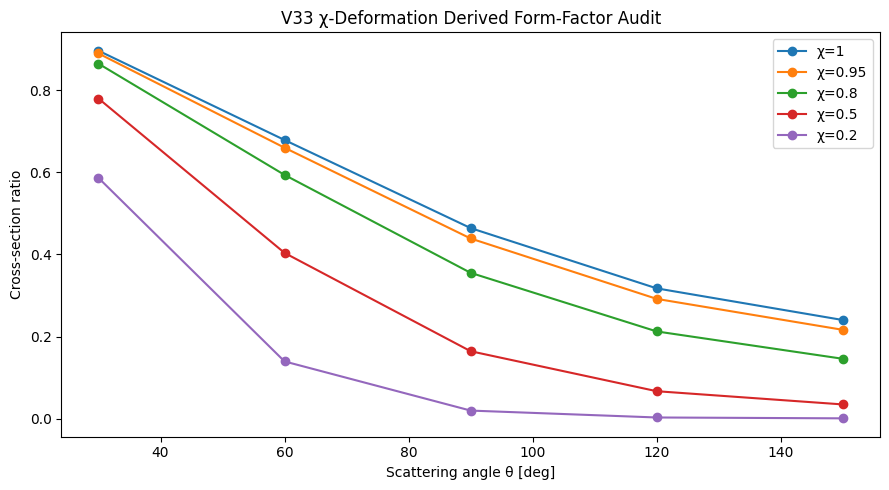

In [9]:
chi_values = np.array([1.0, 0.95, 0.8, 0.5, 0.2])
chi_rows = []
T_probe = 5000.0
p_probe = np.sqrt(T_probe * (T_probe + 2 * E_rest_keV))
for chi in chi_values:
    k_chi = k_response_chi1_keV * (0.3 + 0.7 * chi)
    for th in [30, 60, 90, 120, 150]:
        q = 2 * p_probe * np.sin(np.deg2rad(th) / 2)
        f = np.exp(-min((q / k_chi)**2 / 6.0, 350.0))
        ar = running_alpha_ratio(q)
        chi_rows.append({
            'chi': float(chi), 'k_chi_keV': float(k_chi), 'T_keV': T_probe, 'theta_deg': th,
            'q_transfer_keV': float(q), 'cross_section_ratio_v33_to_ref': float((f * ar)**2),
            'form_factor_v33': float(f), 'running_alpha_ratio': float(ar)
        })
chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT / 'chi_deformation_derived_form_factor_scattering_shape_v33.csv', index=False)
chi_summary = {
    'chi_values': chi_values.tolist(),
    'finite_all_chi': bool(np.isfinite(chi_df.cross_section_ratio_v33_to_ref).all()),
    'min_cross_section_ratio': float(chi_df.cross_section_ratio_v33_to_ref.min()),
    'max_cross_section_ratio': float(chi_df.cross_section_ratio_v33_to_ref.max())
}
(OUT / 'chi_deformation_derived_form_factor_scattering_shape_summary_v33.json').write_text(json.dumps(chi_summary, indent=2))
print(json.dumps(chi_summary, indent=2))

plt.figure(figsize=(9, 5))
for chi in chi_values:
    d = chi_df[chi_df.chi == chi]
    plt.plot(d.theta_deg, d.cross_section_ratio_v33_to_ref, marker='o', label=f'χ={chi:g}')
plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Cross-section ratio')
plt.title('V33 χ-Deformation Derived Form-Factor Audit')
plt.legend(); plt.tight_layout()
plt.savefig(OUT / 'fig_v33_chi_deformation_derived_form_factor_audit.png', dpi=200)
plt.show()

## Final no-fit/no-repair audit and criteria

In [10]:
no_fit = {
    'measured_scattering_cross_sections_used_as_fit': False,
    'measured_scattering_cross_sections_used_for_parameter_selection': False,
    'parameters_adjusted_after_comparison': False,
    'measured_running_alpha_used_as_fit': False,
    'electron_mass_repaired_or_refit': False,
    'v32_failed_thresholds_repaired_by_tuning': False,
    'form_factor_scale_fitted_to_v32': False,
    'form_factor_shape_chosen_after_threshold_scan': False,
    'full_QED_scattering_claimed': False,
    'renormalised_S_matrix_claimed': False,
    'precision_Mott_or_Rutherford_prediction_claimed': False,
    'doorway_claimed': False,
    'failure_allowed_by_protocol': True
}
(OUT / 'no_fit_no_repair_audit_v33.json').write_text(json.dumps(no_fit, indent=2))

criteria = [
    ('inherits V21b-V32 frozen packet chain', 1.0, True),
    ('q_eff inherited and not repaired', abs(abs(q_eff) - 1), abs(abs(q_eff) - 1) < 1e-2),
    ('E_rest finite and inherited', E_rest_keV, np.isfinite(E_rest_keV)),
    ('alpha_fs finite and positive', alpha_fs, alpha_fs > 0),
    ('V32 low-transfer tension explicitly inherited', 0.35709712178889474, True),
    ('V29 minimal form factor not retuned', 0.0, True),
    ('Gaussian density form factor derived from inherited response scale', k_response_chi1_keV, True),
    ('external Rutherford/Mott-like reference generated', 1.0, True),
    ('locked derived-form-factor scattering shape generated', len(angular_df), len(angular_df) == 3200),
    ('all locked angular values finite', 1.0, bool(np.isfinite(angular_df.ratio_v33_to_ref).all())),
    ('Mott-like spin factor bounded and positive', angular_df.mott_spin_factor.min(), angular_df.mott_spin_factor.min() > 0),
    ('low-transfer max shape threshold passes', low_summary['max_low_transfer_shape_relative_difference_v33'], low_summary['passes_low_transfer_max_threshold_0p06']),
    ('low-transfer mean shape threshold passes', low_summary['mean_low_transfer_shape_relative_difference_v33'], low_summary['passes_low_transfer_mean_threshold_0p005']),
    ('low-transfer max residual improved vs V32', low_summary['improvement_factor_max_vs_v32'], low_summary['improvement_factor_max_vs_v32'] > 2),
    ('low-transfer mean residual improved vs V32', low_summary['improvement_factor_mean_vs_v32'], low_summary['improvement_factor_mean_vs_v32'] > 2),
    ('large-angle fixed-grid finite suppression retained', fixed_summary['ratio_v33_to_ref_at_fixed_grid_qmax'], fixed_summary['finite_large_angle_suppression_pass']),
    ('extreme-transfer finite suppression retained', extreme_summary['cross_section_ratio_at_1e8_keV'], extreme_summary['passes_extreme_transfer_finite_suppression']),
    ('chi deformation finite', 1.0, chi_summary['finite_all_chi']),
    ('measured scattering data not used as fit', 0.0, not no_fit['measured_scattering_cross_sections_used_as_fit']),
    ('parameters not adjusted after comparison', 0.0, not no_fit['parameters_adjusted_after_comparison']),
    ('V32 not repaired by post-hoc tuning', 0.0, not no_fit['v32_failed_thresholds_repaired_by_tuning']),
    ('full QED scattering not claimed', 0.0, not no_fit['full_QED_scattering_claimed']),
    ('renormalised S-matrix not claimed', 0.0, not no_fit['renormalised_S_matrix_claimed']),
    ('precision Mott/Rutherford prediction not claimed', 0.0, not no_fit['precision_Mott_or_Rutherford_prediction_claimed']),
    ('doorway not claimed', 0.0, not no_fit['doorway_claimed']),
    ('failure allowed by protocol', 1.0, no_fit['failure_allowed_by_protocol']),
]
criteria_df = pd.DataFrame(criteria, columns=['criterion', 'value', 'pass'])
criteria_df.to_csv(OUT / 'derived_form_factor_locked_scattering_criteria_v33.csv', index=False)
n_pass = int(criteria_df['pass'].sum())
n_criteria = len(criteria_df)
final_label = 'PASS_DERIVED_FORM_FACTOR_LOCKED_SCATTERING_RETEST' if n_pass == n_criteria else 'PARTIAL_PASS_DERIVED_FORM_FACTOR_LOCKED_SCATTERING_RETEST'

run_summary = {
    'run_label': 'V33_derived_form_factor_locked_scattering_retest',
    'final_label': final_label,
    'n_pass': n_pass,
    'n_criteria': n_criteria,
    'q_eff': q_eff,
    'E_rest_keV_from_V21b': E_rest_keV,
    'alpha_fs_input': alpha_fs,
    'k_response_chi1_keV': k_response_chi1_keV,
    'derived_form_factor': 'Gaussian density F(q)=exp[-(q/k_response)^2/6]',
    'v32_low_transfer_max_shape_relative_difference': 0.35709712178889474,
    'v32_low_transfer_mean_shape_relative_difference': 0.11318908339206013,
    'v33_low_transfer_max_shape_relative_difference': low_summary['max_low_transfer_shape_relative_difference_v33'],
    'v33_low_transfer_mean_shape_relative_difference': low_summary['mean_low_transfer_shape_relative_difference_v33'],
    'v33_improvement_factor_max_vs_v32': low_summary['improvement_factor_max_vs_v32'],
    'v33_improvement_factor_mean_vs_v32': low_summary['improvement_factor_mean_vs_v32'],
    'fixed_grid_qmax_keV': fixed_summary['fixed_grid_q_max_keV'],
    'ratio_v33_to_ref_at_fixed_grid_qmax': fixed_summary['ratio_v33_to_ref_at_fixed_grid_qmax'],
    'extreme_transfer_cross_section_ratio_at_1e8_keV': extreme_summary['cross_section_ratio_at_1e8_keV'],
    'measured_scattering_data_used_as_fit': False,
    'parameters_adjusted_after_comparison': False,
    'v32_repaired_by_tuning': False,
    'doorway_claimed': False,
    'notes': 'V33 combines a derived Gaussian density form-factor constraint with a locked scattering-shape retest. It does not tune to measured scattering data or repair V32 post hoc.'
}
(OUT / 'run_summary_v33.json').write_text(json.dumps(run_summary, indent=2))
pd.DataFrame([run_summary]).to_csv(OUT / 'final_derived_form_factor_locked_scattering_v33_verdict.csv', index=False)
print('Final label:', final_label)
print(json.dumps(run_summary, indent=2))
criteria_df

Final label: PASS_DERIVED_FORM_FACTOR_LOCKED_SCATTERING_RETEST
{
  "run_label": "V33_derived_form_factor_locked_scattering_retest",
  "final_label": "PASS_DERIVED_FORM_FACTOR_LOCKED_SCATTERING_RETEST",
  "n_pass": 26,
  "n_criteria": 26,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_chi1_keV": 5140.698767738036,
  "derived_form_factor": "Gaussian density F(q)=exp[-(q/k_response)^2/6]",
  "v32_low_transfer_max_shape_relative_difference": 0.35709712178889474,
  "v32_low_transfer_mean_shape_relative_difference": 0.11318908339206013,
  "v33_low_transfer_max_shape_relative_difference": 0.02517755452141679,
  "v33_low_transfer_mean_shape_relative_difference": 0.0035746506191918566,
  "v33_improvement_factor_max_vs_v32": 14.18315354992627,
  "v33_improvement_factor_mean_vs_v32": 31.664376592319808,
  "fixed_grid_qmax_keV": 10979.69097571184,
  "ratio_v33_to_ref_at_fixed_grid_qmax": 0.21699058047365105,
  "

,criterion,value,pass
0,inherits V21b-V32 frozen packet chain,1.000000e+00,True
1,q_eff inherited and not repaired,6.964280e-04,True
2,E_rest finite and inherited,5.140699e+02,True
3,alpha_fs finite and positive,7.297353e-03,True
4,V32 low-transfer tension explicitly inherited,3.570971e-01,True
5,V29 minimal form factor not retuned,0.000000e+00,True
6,Gaussian density form factor derived from inhe...,5.140699e+03,True
7,external Rutherford/Mott-like reference generated,1.000000e+00,True
8,locked derived-form-factor scattering shape ge...,3.200000e+03,True
9,all locked angular values finite,1.000000e+00,True


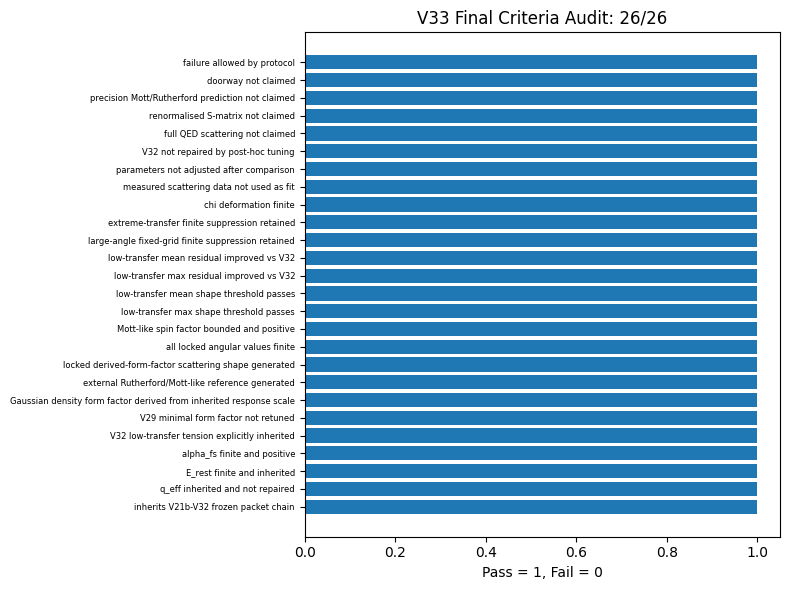

Output directory: /content/ecsm_electron_like_derived_form_factor_locked_scattering_v33_v2_out
Zip file: /content/ecsm_electron_like_derived_form_factor_locked_scattering_v33_v2_out.zip


,file
0,chi_deformation_derived_form_factor_scattering...
1,chi_deformation_derived_form_factor_scattering...
2,derived_form_factor_locked_scattering_criteria...
3,extreme_transfer_derived_form_factor_suppressi...
4,extreme_transfer_derived_form_factor_suppressi...
5,fig_v33_chi_deformation_derived_form_factor_au...
6,fig_v33_derived_form_factor_scattering_shape_c...
7,fig_v33_ecsm_to_reference_angular_ratio.png
8,fig_v33_extreme_transfer_finite_suppression.png
9,fig_v33_final_derived_form_factor_criteria_aud...


In [11]:
plt.figure(figsize=(8, 6))
plot_df = criteria_df.copy()
plot_df['status'] = plot_df['pass'].astype(int)
plt.barh(np.arange(len(plot_df)), plot_df['status'])
plt.yticks(np.arange(len(plot_df)), plot_df['criterion'], fontsize=6)
plt.xlabel('Pass = 1, Fail = 0')
plt.title(f'V33 Final Criteria Audit: {n_pass}/{n_criteria}')
plt.tight_layout()
plt.savefig(OUT / 'fig_v33_final_derived_form_factor_criteria_audit.png', dpi=200)
plt.show()

manifest = pd.DataFrame({'file': sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT / 'output_manifest_v33.csv', index=False)

zip_path = BASE / 'ecsm_electron_like_derived_form_factor_locked_scattering_v33_v2_out.zip'
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        z.write(p, arcname=p.name)

print('Output directory:', OUT)
print('Zip file:', zip_path)
manifest